In [1]:
# notebook to plot the results of the optimized chi sq processing

In [1]:
# test one star - read in data from one star and plot it up
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from astropy.table import Table, join, vstack, hstack
from astropy.io import fits, ascii


In [3]:
# plotting parameters
plt.rc('axes', labelsize=12)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='5'
plt.rcParams['ytick.major.pad']='5'

#paper_params = {
#        #'text.usetex' : True,
#        'font.size'   : 10,
#        #'font.family' : 'lmodern',
#        'figure.dpi'  : 200
#        }
#plt.rcParams.update(paper_params)


In [4]:
def read_parameter_stats(star_name):
    """Read and display parameter statistics from file with error bars"""
    
    stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_numba_FULL_GRID'
    stats_file = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
    
    # Initialize dictionaries to store statistics
    stats = {
        'metallicity': {},
        'agb_mass': {},
        'initial_mass': {},
        'final_mass': {},
        'mass_ratio': {},
        'accreted_mass': {}
    }
    
    with open(stats_file, 'r') as f:
        lines = f.readlines()
        
        current_section = None
        reading_probs = False  # Flag to track when we're reading probability distributions
        
        for line in lines:
            line = line.strip()
            if not line or '=====' in line:
                continue
                
            if 'Metallicity' in line:
                current_section = 'metallicity'
                reading_probs = False
                #print(f'\n{line}')
            elif 'AGB Mass' in line:
                current_section = 'agb_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Initial Mass' in line:
                current_section = 'initial_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Final Mass' in line:
                current_section = 'final_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Mass Ratio' in line:
                current_section = 'mass_ratio'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Accreted Mass' in line:
                current_section = 'accreted_mass'
                reading_probs = False
                #print(f'\n{line}')
            elif 'Probability distribution:' in line:
                reading_probs = True
                continue
                
            if not reading_probs:
                if 'Mean:' in line:
                    stats[current_section]['mean'] = float(line.split(':')[1])
                    #print(line)
                elif 'Median:' in line:
                    stats[current_section]['median'] = float(line.split(':')[1])
                    #print(line)
                elif 'confidence' in line:
                    intervals = line.split('[')[1].split(']')[0].split(',')
                    stats[current_section]['conf_lower'] = float(intervals[0])
                    stats[current_section]['conf_upper'] = float(intervals[1])
                    
                    # Calculate uncertainties
                    if 'median' in stats[current_section]:
                        median = stats[current_section]['median']
                        stats[current_section]['err_lower'] = median - float(intervals[0])
                        stats[current_section]['err_upper'] = float(intervals[1]) - median
                        # Calculate median uncertainty as half the confidence interval
                        conf_range = float(intervals[1]) - float(intervals[0])
                        stats[current_section]['median_err'] = conf_range / 2
                    #print(line)
            else:
                # Only process probability distribution lines with valid number pairs
                if ':' in line:
                    try:
                        val, prob = line.split(':')
                        val = float(val)
                        prob = float(prob)
                        
                        if 'prob_dist' not in stats[current_section]:
                            stats[current_section]['prob_dist'] = {'values': [], 'probs': []}
                        stats[current_section]['prob_dist']['values'].append(val)
                        stats[current_section]['prob_dist']['probs'].append(prob)
                    except ValueError:
                        continue
                
    # Calculate standard errors for each parameter
    for param in stats:
        if 'prob_dist' in stats[param]:
            values = np.array(stats[param]['prob_dist']['values'])
            probs = np.array(stats[param]['prob_dist']['probs'])
            mean = stats[param]['mean']
            # Calculate standard error
            variance = np.sum(probs * (values - mean)**2)
            stats[param]['std_err'] = np.sqrt(variance)
    
    return stats

In [5]:
def plot_parameter_stats(star_name, timeout=10):
    """Plot parameter statistics read from file with probability distributions"""
    import signal
    
    def timeout_handler(signum, frame):
        raise TimeoutError(f"File reading took too long for {star_name}")
    
    try:
        stats = read_parameter_stats(star_name)
        
        # Read the probability distributions from file
        stats_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_numba_FULL_GRID'
        stats_file = os.path.join(stats_dir, f'parameter_stats_{star_name}.txt')
        
        if not os.path.exists(stats_file):
            print(f"Statistics file for {star_name} not found: {stats_file}")
            return None, stats
        
        # Initialize arrays for values and probabilities
        metal_vals, metal_probs = [], []
        agb_vals, agb_probs = [], []
        init_vals, init_probs = [], []
        final_vals, final_probs = [], []
        mass_ratio_vals, mass_ratio_probs = [], []
        accreted_mass_vals, accreted_mass_probs = [], []
        
        # Read probability distributions from file with timeout protection
        current_section = None
        line_count = 0
        max_lines = 100000  # Safety limit
        
        with open(stats_file, 'r') as f:
            for line in f:
                line_count += 1
                if line_count > max_lines:
                    print(f"Warning: Exceeded max line limit while reading {star_name}")
                    break
                    
                if 'Probability distribution:' in line:
                    continue
                if 'Metallicity' in line:
                    current_section = 'metallicity'
                    continue
                elif 'AGB Mass' in line:
                    current_section = 'agb_mass'
                    continue  
                elif 'Initial Mass' in line:
                    current_section = 'initial_mass'
                    continue
                elif 'Final Mass' in line:
                    current_section = 'final_mass'
                    continue
                elif 'Mass Ratio' in line:
                    current_section = 'mass_ratio'
                    continue
                elif 'Accreted Mass' in line:
                    current_section = 'accreted_mass'
                    continue
                    
                # Parse probability distribution lines
                if ':' in line and not any(x in line for x in ['Mean:', 'Median:', 'confidence']):
                    try:
                        parts = line.strip().split(':')
                        if len(parts) == 2:
                            val, prob = float(parts[0]), float(parts[1])
                            if current_section == 'metallicity':
                                metal_vals.append(val)
                                metal_probs.append(prob)
                            elif current_section == 'agb_mass':
                                agb_vals.append(val)
                                agb_probs.append(prob)
                            elif current_section == 'initial_mass':
                                init_vals.append(val)
                                init_probs.append(prob)
                            elif current_section == 'final_mass':
                                final_vals.append(val)
                                final_probs.append(prob)
                            elif current_section == 'mass_ratio':
                                mass_ratio_vals.append(val)
                                mass_ratio_probs.append(prob)
                            elif current_section == 'accreted_mass':
                                accreted_mass_vals.append(val)
                                accreted_mass_probs.append(prob)
                    except (ValueError, IndexError):
                        continue
        
        fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3, figsize=(15, 10))
        
        # Plot Metallicity distribution
        ax1.hist(metal_vals, weights=metal_probs, density=True, alpha=0.5)
        ax1.axvline(stats['metallicity']['mean'], color='r', ls='--', 
                    label=f"Mean: {stats['metallicity']['mean']:.2f}")
        ax1.axvline(stats['metallicity']['median'], color='g', ls='--', 
                    label=f"Median: {stats['metallicity']['median']:.2f}")
        ax1.axvspan(stats['metallicity']['conf_lower'], stats['metallicity']['conf_upper'],
                    alpha=0.2, color='gray', label='68% conf.')
        ax1.set_xlabel('[Fe/H]')
        ax1.set_yscale('log')
        ax1.legend(fontsize=12)
        
        # Plot AGB Mass distribution  
        ax2.hist(agb_vals, weights=agb_probs, density=True, alpha=0.5)
        ax2.axvline(stats['agb_mass']['mean'], color='r', ls='--', 
                    label=f"Mean: {stats['agb_mass']['mean']:.2f}")
        ax2.axvline(stats['agb_mass']['median'], color='g', ls='--', 
                    label=f"Median: {stats['agb_mass']['median']:.2f}")
        ax2.axvspan(stats['agb_mass']['conf_lower'], stats['agb_mass']['conf_upper'],
                    alpha=0.2, color='gray', label='68% conf.')
        ax2.set_xlabel(r'M$_{AGB}$ (M$_{\odot}$)')
        ax2.set_yscale('log')
        ax2.legend(fontsize=12)
        
        # Plot Initial Mass distribution
        ax3.hist(init_vals, weights=init_probs, density=True, alpha=0.5)
        ax3.axvline(stats['initial_mass']['mean'], color='r', ls='--', 
                    label=f"Mean: {stats['initial_mass']['mean']:.2f}")
        ax3.axvline(stats['initial_mass']['median'], color='g', ls='--', 
                    label=f"Median: {stats['initial_mass']['median']:.2f}")
        ax3.axvspan(stats['initial_mass']['conf_lower'], stats['initial_mass']['conf_upper'],
                    alpha=0.2, color='gray', label='68% conf.')
        ax3.set_xlabel(r'M$_{initial}$ (M$_{\odot}$)')
        ax3.set_yscale('log')
        ax3.legend(fontsize=12)
        
        # Plot Final Mass distribution
        ax4.hist(final_vals, weights=final_probs, density=True, alpha=0.5)
        ax4.axvline(stats['final_mass']['mean'], color='r', ls='--', 
                    label=f"Mean: {stats['final_mass']['mean']:.2f}")
        ax4.axvline(stats['final_mass']['median'], color='g', ls='--', 
                    label=f"Median: {stats['final_mass']['median']:.2f}")
        ax4.axvspan(stats['final_mass']['conf_lower'], stats['final_mass']['conf_upper'],
                    alpha=0.2, color='gray', label='68% conf.')
        ax4.set_xlabel(r'M$_{final}$ (M$_{\odot}$)')
        ax4.set_yscale('log')
        ax4.legend(fontsize=12)

        # Plot mass ratio distribution
        if mass_ratio_vals and 'mass_ratio' in stats and stats['mass_ratio']:
            ax5.hist(mass_ratio_vals, weights=mass_ratio_probs, density=True, alpha=0.5)
            ax5.axvline(stats['mass_ratio']['mean'], color='r', ls='--', 
                        label=f"Mean: {stats['mass_ratio']['mean']:.2f}")
            ax5.axvline(stats['mass_ratio']['median'], color='g', ls='--', 
                        label=f"Median: {stats['mass_ratio']['median']:.2f}")
            ax5.axvspan(stats['mass_ratio']['conf_lower'], stats['mass_ratio']['conf_upper'],
                        alpha=0.2, color='gray', label='68% conf.')
        else:
            ax5.text(0.5, 0.5, 'No mass ratio data', ha='center', va='center', 
                    transform=ax5.transAxes)
        ax5.set_xlabel(r'Mass Ratio (M$_{initial}$/M$_{AGB}$)')
        ax5.set_yscale('log')
        ax5.legend(fontsize=12)

        # Plot accreted mass distribution
        if accreted_mass_vals and 'accreted_mass' in stats and stats['accreted_mass']:
            ax6.hist(accreted_mass_vals, weights=accreted_mass_probs, density=True, alpha=0.5)
            ax6.axvline(stats['accreted_mass']['mean'], color='r', ls='--', 
                        label=f"Mean: {stats['accreted_mass']['mean']:.2f}")
            ax6.axvline(stats['accreted_mass']['median'], color='g', ls='--', 
                        label=f"Median: {stats['accreted_mass']['median']:.2f}")
            ax6.axvspan(stats['accreted_mass']['conf_lower'], stats['accreted_mass']['conf_upper'],
                        alpha=0.2, color='gray', label='68% conf.')
        else:
            ax6.text(0.5, 0.5, 'No accreted mass data', ha='center', va='center', 
                    transform=ax6.transAxes)
        ax6.set_xlabel(r'Accreted Mass (M$_{initial}$ - M$_{final}$) (M$_{\odot}$)')
        ax6.set_yscale('log')
        ax6.legend(fontsize=12)

        plt.suptitle(f'Parameter Statistics for {star_name}', y=1.02)
        plt.tight_layout()
        return fig, stats
        
    except Exception as e:
        print(f"Error processing {star_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

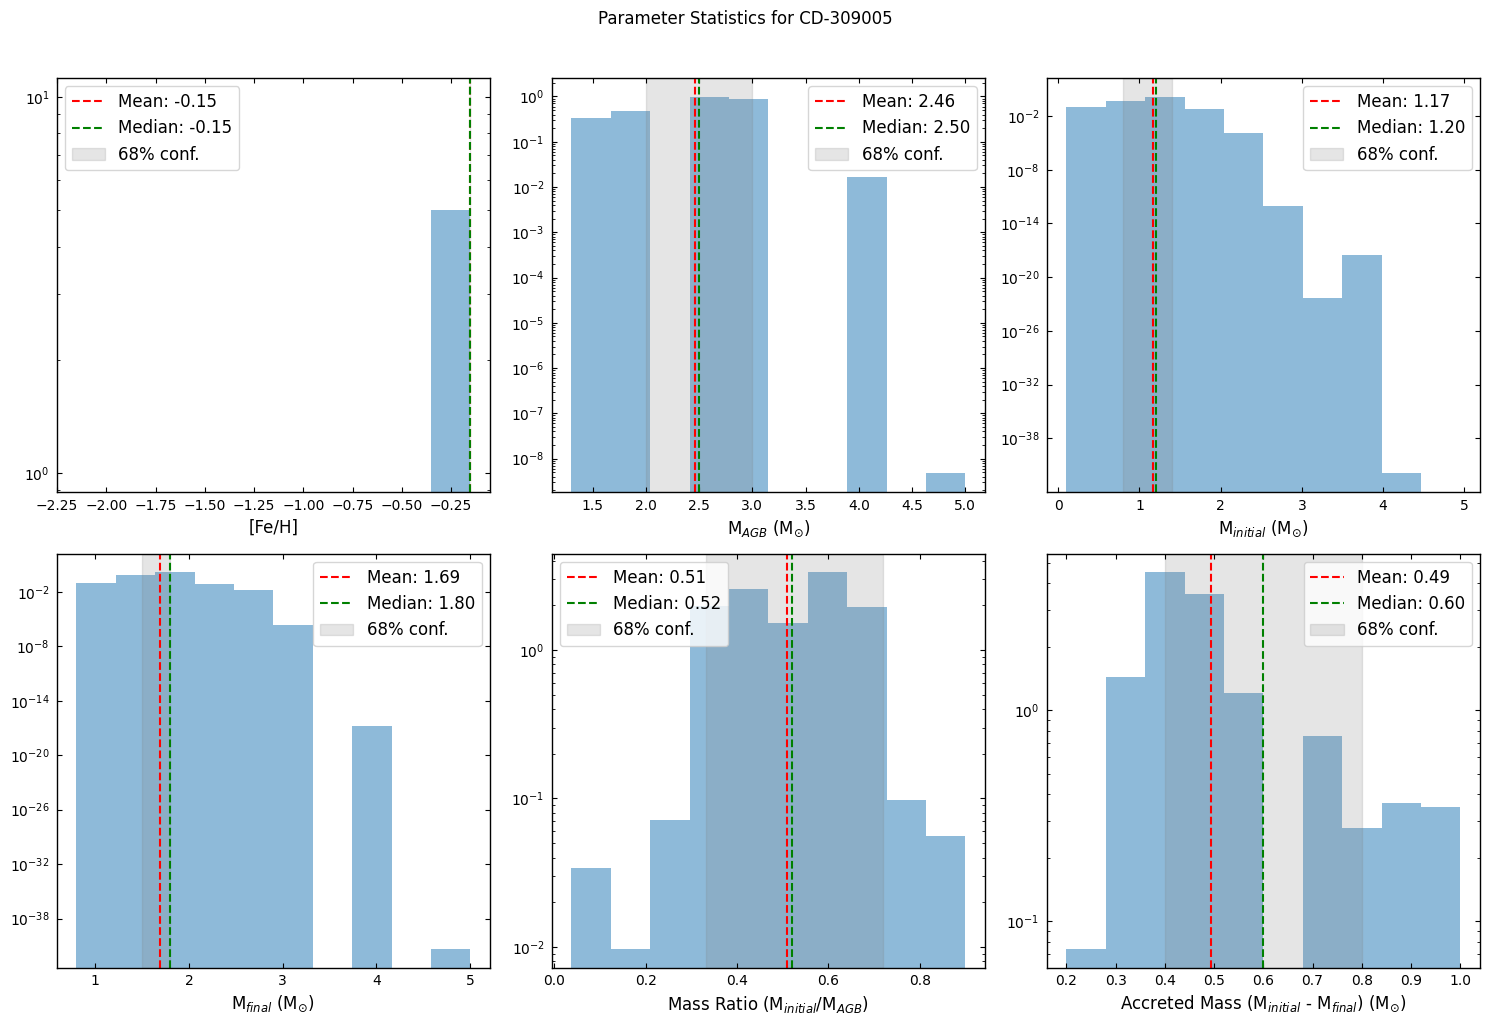

In [7]:
star_name = 'CD-309005'
fig, stats = plot_parameter_stats(star_name)
if fig:
    plt.show()
    #print(stats)

In [8]:
# read all stat files and get list of star names
def get_star_names(stats_dir):
    """Get a list of star names from the statistics directory"""
    star_names = []
    for filename in os.listdir(stats_dir):
        if filename.startswith('parameter_stats_') and filename.endswith('.txt'):
            star_name = filename[len('parameter_stats_'):-len('.txt')]
            star_names.append(star_name)
    return star_names

star_names = get_star_names('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/statistics_numba_FULL_GRID')


In [9]:
# read stellar data from original input files so we can (1) cross match by stellar type, and evolutionary position

data_dir = '/nexus/posix0/MIA-astro-env/hxr/adimoff/abund_data/'
# files to read are: 
# X_Fe_table_3.dat + param_mass_table.dat, (merged on name)
# DeCastro_Roriz_Table.dat, 
# Gos_Rat_Gos_2020.dat, 
# Gos_Rat_Gos_CEMPs_2021.dat, 
# Cristallo_2016.dat

# merge X_Fe_table_3.dat and param_mass_table.dat on name
Obs_Data_Table = ascii.read(os.path.join(data_dir, 'X_Fe_table_3.dat'), delimiter='&')
param_mass_table = ascii.read(os.path.join(data_dir, 'param_mass_table.dat'), format='latex')
full_obs_data_table = join(param_mass_table, Obs_Data_Table, keys='stars')
# convert to data frame
full_obs_data_table = full_obs_data_table.to_pandas()

# lets start with the Ba stars from DeCastro_Roriz_Table.dat
DeCastro_file = os.path.join(data_dir, 'DeCastro_Roriz_Table.dat')
DeCastro_data = pd.read_csv(DeCastro_file, delimiter=' ', comment='#', header=0)

Cristallo_file = os.path.join(data_dir, 'Cristallo_2016.dat')
Cristallo_data = pd.read_csv(Cristallo_file, delimiter=' ', comment='#', header=0)

In [10]:
# sort Cristallo_data by logg
full_obs_data_table = full_obs_data_table.sort_values(by='logg')
full_obs_data_table

,stars,Teff,e_Teff,logg,e_logg,Fe_1,e_Fe,AGB,vis,e_vis,...,Nd_sig,Sm,Sm_sig,Eu,Eu_sig,Dy,Dy_sig,Pb,Pb_sig,Type
5,HD196673,4825,66,0.94,0.37,0.00,0.14,5.0,5.08,0.32,...,0.136015,NaN,NaN,-0.15,0.155242,NaN,NaN,NaN,NaN,B
2,CD-621346,5318,76,1.40,0.28,-1.33,0.10,3.0,2.89,0.87,...,0.184391,NaN,NaN,0.51,0.107703,NaN,NaN,2.06,0.141421,C
6,HD209621,4850,396,1.64,0.33,-1.60,0.30,2.0,2.30,1.10,...,0.203961,NaN,NaN,1.06,0.203961,NaN,NaN,2.06,0.223607,C
0,BD+042466,5021,220,1.68,0.30,-1.93,0.30,2.0,2.40,0.92,...,0.098489,NaN,NaN,0.50,0.155242,NaN,NaN,1.70,0.180278,C
1,BD+412150,4828,84,1.73,0.16,-0.48,0.18,2.0,1.69,0.94,...,0.089443,NaN,NaN,0.32,0.155242,NaN,NaN,0.92,0.180278,C
7,HD31487,4964,80,1.94,0.40,-0.38,0.14,1.5,1.95,0.98,...,0.136015,NaN,NaN,0.15,0.184391,NaN,NaN,NaN,NaN,B
9,HRCMa,5063,75,1.98,0.36,-0.23,0.12,2.5,1.87,0.95,...,0.136015,NaN,NaN,0.31,0.107703,NaN,NaN,1.11,0.180278,B
3,HD104979,5007,53,2.08,0.20,-0.35,0.10,4.0,2.99,1.10,...,0.174642,NaN,NaN,0.25,0.107703,NaN,NaN,1.10,NaN,B
10,PVUMa,5058,74,2.28,0.34,-0.32,0.13,1.5,2.20,0.64,...,0.164924,NaN,NaN,-0.08,0.164924,NaN,NaN,NaN,NaN,B
8,HD50264,5972,45,4.24,0.12,-0.17,0.07,1.5,1.25,0.89,...,0.136015,NaN,NaN,0.26,0.107703,NaN,NaN,1.16,0.180278,B


In [ ]:
# Load the master table and other necessary data
# This is a simplified version - you may need to adjust according to your actual data loading process

# Read in observational data
Obs_Data_Table = ascii.read(os.path.join(data_dir, 'X_Fe_table_3.dat'), delimiter='&')
param_mass_table = ascii.read(os.path.join(data_dir, 'param_mass_table.dat'), format='latex')

full_obs_data_table = join(param_mass_table, Obs_Data_Table, keys='stars')

cristallo_data = ascii.read(os.path.join(data_dir, 'Cristallo_2016.dat'))
goswami_2020_data = ascii.read(os.path.join(data_dir, 'Gos_Rat_Gos_2020.dat'))
goswami_2021_data = ascii.read(os.path.join(data_dir, 'Gos_Rat_Gos_CEMPs_2021.dat'))
DeCastro_Roriz = ascii.read(os.path.join(data_dir, 'DeCastro_Roriz_Table.dat'))
# Stack all tables
master_table = vstack([full_obs_data_table, cristallo_data, goswami_2020_data, goswami_2021_data, DeCastro_Roriz], join_type='inner') # SAGA_MP, SAGA_MR
obs_names = np.array(['C','C_sig','FeH','FeH_sig','Sr','Sr_sig','Y','Y_sig','Zr','Zr_sig','Nb','Nb_sig','Mo','Mo_sig','Ru','Ru_sig','Ba','Ba_sig','La','La_sig','Ce','Ce_sig','Pr','Pr_sig','Nd','Nd_sig','Sm','Sm_sig','Eu','Eu_sig','Dy','Dy_sig','Pb','Pb_sig'])

print(f"Loaded master_table with {len(master_table)} rows")
# convert master_table to pandas dataframe
master_table = master_table.to_pandas()


Loaded master_table with 283 rows


In [82]:
master_table.sort_values(by='FeH')

,stars,Teff,e_Teff,logg,e_logg,FeH,FeH_sig,C,C_sig,Sr,...,Nd,Nd_sig,Sm,Sm_sig,Eu,Eu_sig,Dy,Dy_sig,Pb,Pb_sig
61,CS29497-034,4800.0,300.0,1.80,0.3,-3.00,0.250000,2.61,0.250000,1.20,...,2.16,0.250000,NaN,0.25,2.03,0.250000,NaN,NaN,2.95,0.250000
106,HE2158-5134,4950.0,100.0,1.90,0.2,-3.00,0.250000,2.60,0.250000,2.60,...,1.80,0.250000,NaN,0.25,NaN,0.250000,NaN,NaN,NaN,0.250000
116,SDSSJ1349-0229,6200.0,300.0,4.00,0.3,-3.00,0.250000,2.82,0.250000,1.30,...,1.91,0.250000,2.35,0.25,1.62,0.250000,NaN,NaN,3.09,0.250000
52,CS22183-015,5470.0,100.0,2.85,0.1,-2.91,0.250000,2.13,0.250000,0.44,...,1.78,0.250000,NaN,0.25,1.49,0.250000,NaN,NaN,2.99,0.250000
101,HE1509-0806,5185.0,300.0,2.50,0.3,-2.91,0.250000,1.98,0.250000,1.12,...,2.18,0.250000,NaN,0.25,0.93,0.250000,NaN,NaN,2.61,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,HD204075,5300.0,120.0,1.50,0.3,0.06,0.170000,NaN,NaN,0.86,...,0.71,0.200000,0.38,0.24,0.05,0.180000,NaN,NaN,NaN,NaN
183,HD182300,5000.0,120.0,2.70,0.3,0.06,0.160000,NaN,NaN,0.81,...,0.90,0.200000,0.63,0.23,0.13,0.180000,NaN,NaN,NaN,NaN
257,HD61332,4700.0,120.0,2.10,0.3,0.07,0.130000,NaN,NaN,0.39,...,0.42,0.200000,0.40,0.26,-0.08,0.170000,NaN,NaN,NaN,NaN
4,HD105671,4700.0,150.0,4.50,0.3,0.10,0.250000,0.01,0.094340,0.19,...,0.31,0.164924,NaN,NaN,0.26,0.136015,NaN,NaN,0.21,0.180278


In [13]:
# for list of stars, extract mean, median, conf intervals, and std err to a table
def compile_statistics_table(star_names):
    """Compile statistics for a list of stars into a summary table"""
    all_stats = []
    
    for star in star_names:
        stats = read_parameter_stats(star)
        if stats:
            row = {
                'Star': star,
                'Metallicity_Mean': stats['metallicity'].get('mean', np.nan),
                'Metallicity_Median': stats['metallicity'].get('median', np.nan),
                'Metallicity_Conf_Lower': stats['metallicity'].get('conf_lower', np.nan),
                'Metallicity_Conf_Upper': stats['metallicity'].get('conf_upper', np.nan),
                'Metallicity_Std_Err': stats['metallicity'].get('std_err', np.nan),
                
                'AGB_Mass_Mean': stats['agb_mass'].get('mean', np.nan),
                'AGB_Mass_Median': stats['agb_mass'].get('median', np.nan),
                'AGB_Mass_Conf_Lower': stats['agb_mass'].get('conf_lower', np.nan),
                'AGB_Mass_Conf_Upper': stats['agb_mass'].get('conf_upper', np.nan),
                'AGB_Mass_Std_Err': stats['agb_mass'].get('std_err', np.nan),

                'Initial_Mass_Mean': stats['initial_mass'].get('mean', np.nan),
                'Initial_Mass_Median': stats['initial_mass'].get('median', np.nan),
                'Initial_Mass_Conf_Lower': stats['initial_mass'].get('conf_lower', np.nan),
                'Initial_Mass_Conf_Upper': stats['initial_mass'].get('conf_upper', np.nan),
                'Initial_Mass_Std_Err': stats['initial_mass'].get('std_err', np.nan),

                'Final_Mass_Mean': stats['final_mass'].get('mean', np.nan),
                'Final_Mass_Median': stats['final_mass'].get('median', np.nan),
                'Final_Mass_Conf_Lower': stats['final_mass'].get('conf_lower', np.nan),
                'Final_Mass_Conf_Upper': stats['final_mass'].get('conf_upper', np.nan),
                'Final_Mass_Std_Err': stats['final_mass'].get('std_err', np.nan),
                
                'Mass_Ratio_q_Mean': stats['mass_ratio'].get('mean', np.nan),
                'Mass_Ratio_q_Median': stats['mass_ratio'].get('median', np.nan),
                'Mass_Ratio_q_Conf_Lower': stats['mass_ratio'].get('conf_lower', np.nan),
                'Mass_Ratio_q_Conf_Upper': stats['mass_ratio'].get('conf_upper', np.nan),
                'Mass_Ratio_q_Std_Err': stats['mass_ratio'].get('std_err', np.nan),
                
                'Accreted_Mass_Mean': stats['accreted_mass'].get('mean', np.nan),
                'Accreted_Mass_Median': stats['accreted_mass'].get('median', np.nan),
                'Accreted_Mass_Conf_Lower': stats['accreted_mass'].get('conf_lower', np.nan),
                'Accreted_Mass_Conf_Upper': stats['accreted_mass'].get('conf_upper', np.nan),
                'Accreted_Mass_Std_Err': stats['accreted_mass'].get('std_err', np.nan),
            }
            all_stats.append(row)

    # Convert to DataFrame and save to file
    df = pd.DataFrame(all_stats)
    #df.to_csv(output_file, index=False)
    return df

In [14]:
all_stats = compile_statistics_table(star_names)
len(all_stats)

272

<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:11: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences wil

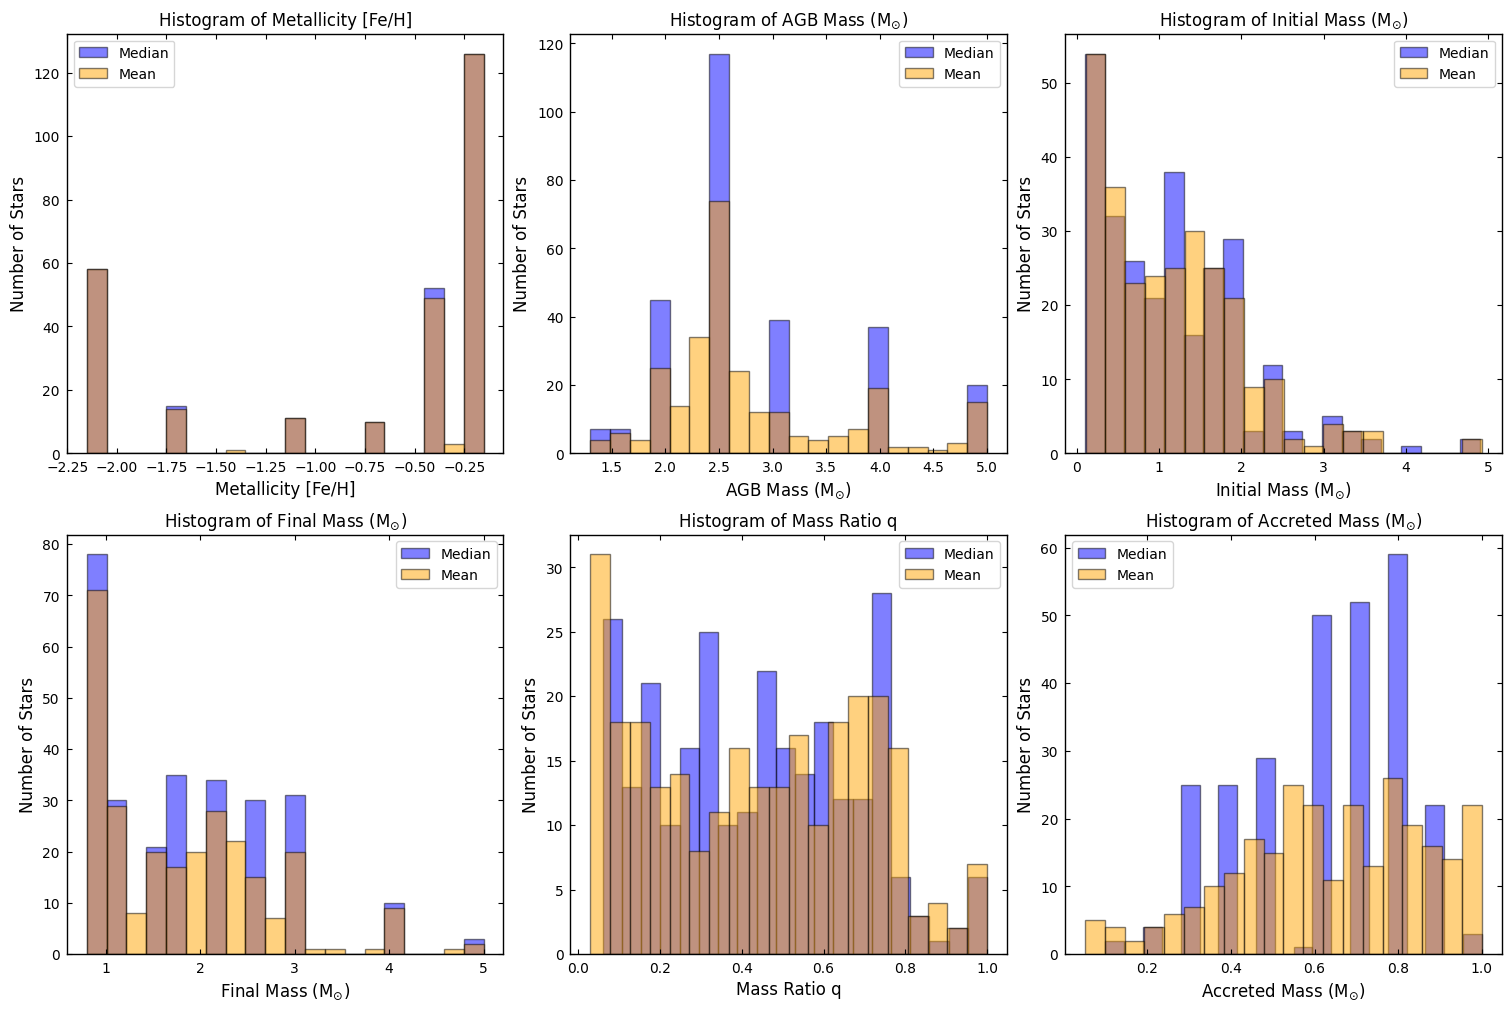

In [16]:
# plot histograms of all medians for each of the 4 parameters
def plot_all_median_histograms(all_stats):
    """Plot histograms of median values for all stars"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), layout='constrained')
    
    median_params = ['Metallicity_Median', 'AGB_Mass_Median', 'Initial_Mass_Median', 'Final_Mass_Median', 'Mass_Ratio_q_Median', 'Accreted_Mass_Median']
    mean_params = ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean']
    mean_plus = ['Metallicity_Conf_Upper', 'AGB_Mass_Conf_Upper', 'Initial_Mass_Conf_Upper', 'Final_Mass_Conf_Upper', 'Mass_Ratio_q_Conf_Upper', 'Accreted_Mass_Conf_Upper']
    mean_minus = ['Metallicity_Conf_Lower', 'AGB_Mass_Conf_Lower', 'Initial_Mass_Conf_Lower', 'Final_Mass_Conf_Lower', 'Mass_Ratio_q_Conf_Lower', 'Accreted_Mass_Conf_Lower']

    titles = ['Metallicity [Fe/H]', 'AGB Mass (M$_{\odot}$)', 'Initial Mass (M$_{\odot}$)', 'Final Mass (M$_{\odot}$)', 'Mass Ratio q', 'Accreted Mass (M$_{\odot}$)']

    for ax, med_param, mean_param, mean_plus, mean_minus, title in zip(axes.flatten(), median_params, mean_params, mean_plus, mean_minus, titles):
        ax.hist(all_stats[med_param].dropna(), bins=20, alpha=0.5, color='blue', edgecolor='black', label='Median')
        ax.hist(all_stats[mean_param].dropna(), bins=20, alpha=0.5, color='orange', edgecolor='black', label='Mean')
        # use mean_plus and minus to plot error bars on the mean values
        #for mean, plus, minus in zip(all_stats[mean_param], all_stats[mean_plus], all_stats[mean_minus]):
        #    if not np.isnan(mean) and not np.isnan(plus) and not np.isnan(minus):
        #        ax.errorbar(mean, 0, xerr=[[mean - minus], [plus - mean]], fmt='o', color='red', label='Mean ± 68% conf.' if mean_param == mean_params[0] else "")
        ax.set_title(f'Histogram of {title}')
        ax.set_xlabel(title)
        ax.set_ylabel('Number of Stars')
        ax.legend(loc='best')
    
    #plt.tight_layout()
    #plt.show()

plot_all_median_histograms(all_stats)

In [15]:
#all_stats['Mass_Ratio_q_Mean'] = all_stats['Initial_Mass_Mean'] / all_stats['AGB_Mass_Mean']
#all_stats['Accreted_Mass_Mean'] = all_stats['Final_Mass_Mean'] - all_stats['Initial_Mass_Mean']

In [17]:
# match star names to master_model_hist_list_mass_limit_weights_stats to get other parameters
from astropy.io import ascii
from astropy.table import Table, vstack, join
info_table = ascii.read('/nexus/posix0/MIA-astro-env/hxr/adimoff/BinaryStars/Accretion_New/master_model_hist_list_numba_FULL_GRID.dat')


In [18]:
# match star names in all_stats with first time they appear in info_table, and add the last column of info_table to all_stats
# the resulting table should look just like all_stats, but the last column is 'type' from info_table
info_df = info_table.to_pandas()
info_df = info_df.rename(columns={'col7': 'Type'})
info_df = info_df[['col1', 'Type']].drop_duplicates(subset='col1', keep='first')
all_stats = all_stats.merge(info_df, left_on='Star', right_on='col1', how='left')
all_stats = all_stats.rename(columns={'Type': 'Star_Type'})
all_stats = all_stats.drop(columns=['col1'])
print(len(all_stats))

272


In [19]:
metal_bins = np.linspace(-2.5,0.00,9)
agb_bins = np.linspace(1.3,5.0,8)
minit_bins = np.linspace(0.00,4.95,15)
mfinal_bins = np.linspace(0.80,5.00,15)
q_bins = np.linspace(0.0,1.0,15)
macc_bins = np.linspace(0.0,1.0,11)

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not w

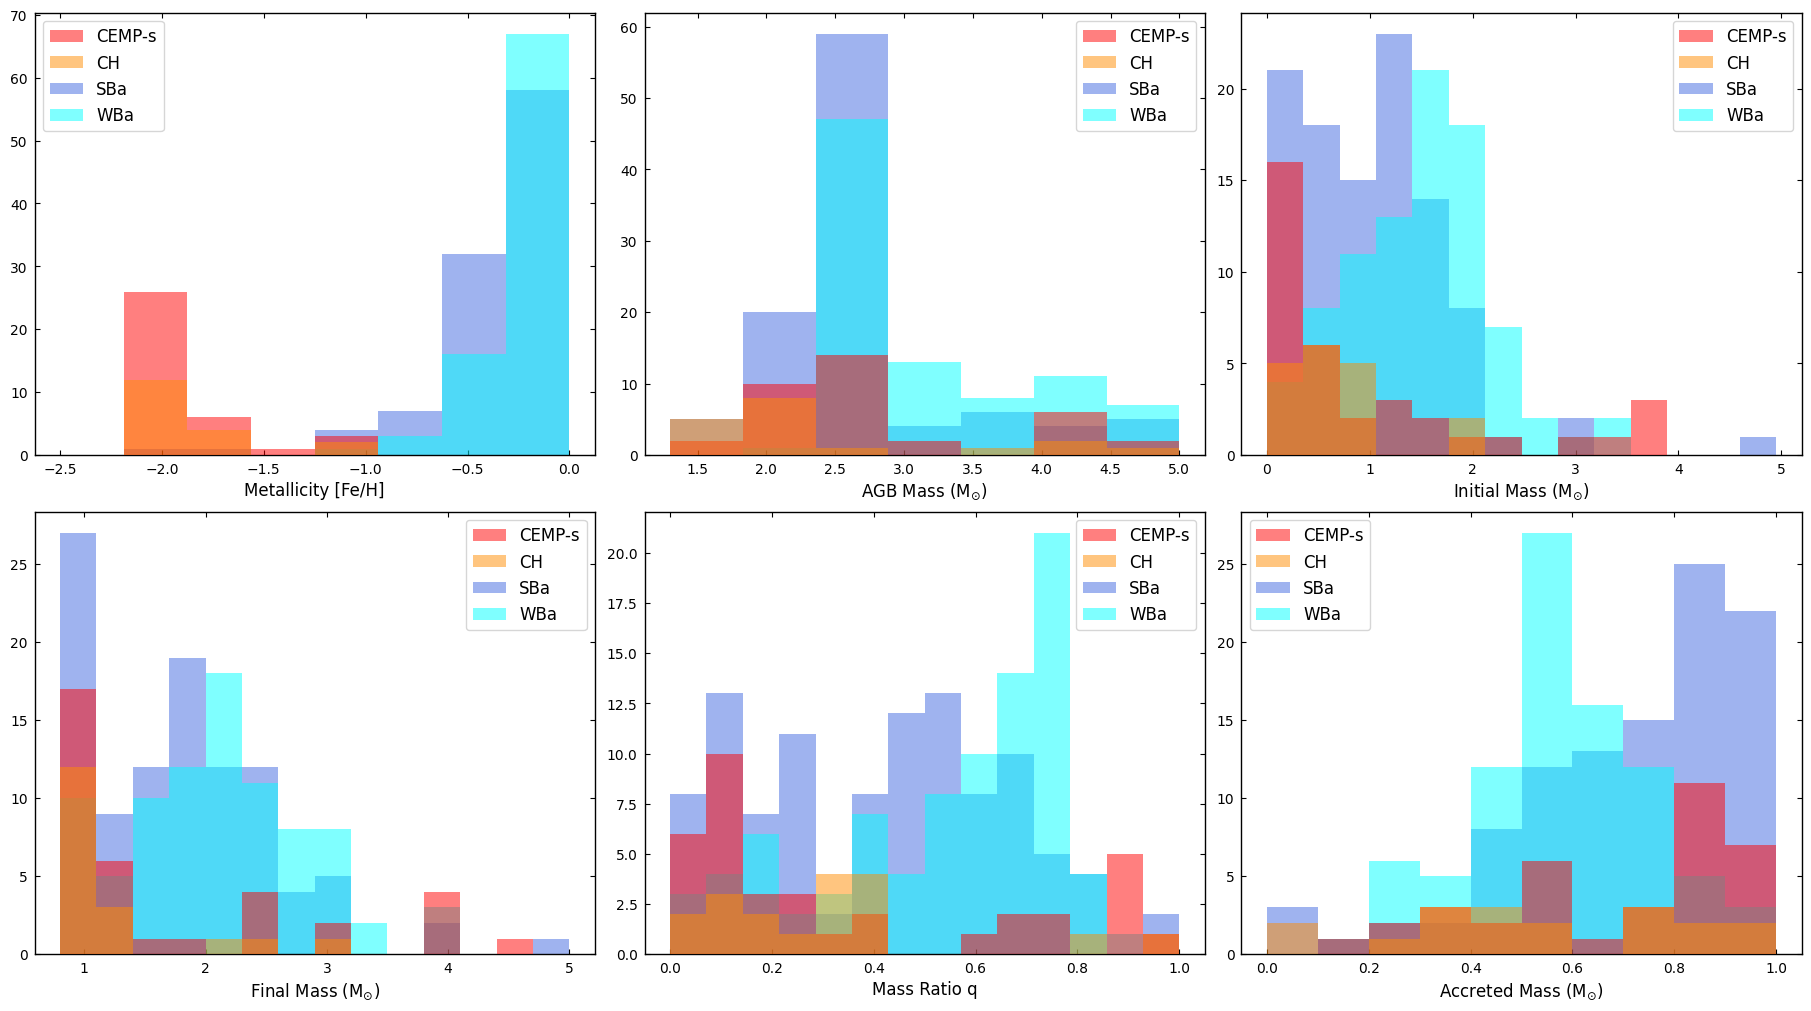

In [20]:
# plot histograms of all medians for each of the 4 parameters, split by the stellar type if available
def plot_all_median_histograms(all_stats):
    """Plot histograms of median values for all stars"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), layout='constrained')
    all_types = np.unique(all_stats['Star_Type'])

    xlabels = ['Metallicity [Fe/H]', 'AGB Mass (M$_{\odot}$)', 'Initial Mass (M$_{\odot}$)', 'Final Mass (M$_{\odot}$)', 'Mass Ratio q', 'Accreted Mass (M$_{\odot}$)']
    for star_type in all_types:
        # combine CEMP-r/s with CEMP-s
        if star_type == 'CEMP-r/s':
            star_type = 'CEMP-s'
            type_stats = all_stats[all_stats['Star_Type'] == star_type]

            for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
               ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='red', zorder=3)
               ax.legend(fontsize=12)
               ax.set_xlabel(xlabel)

        elif star_type == 'CH':
            type_stats = all_stats[all_stats['Star_Type'] == star_type]
            for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
               ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='darkorange', zorder=4)
               ax.legend(fontsize=12)
               ax.set_xlabel(xlabel)

        elif star_type == 'WBa':
            type_stats = all_stats[all_stats['Star_Type'] == star_type]
            for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
               ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='cyan', zorder=2)
               ax.legend(fontsize=12)
               ax.set_xlabel(xlabel)

        elif star_type == 'SBa':
            type_stats = all_stats[all_stats['Star_Type'] == star_type]
            for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
               ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='royalblue', zorder=1)
               ax.legend(fontsize=12)
               ax.set_xlabel(xlabel)


    #for ax, mean_param, title in zip(axes.flatten(), mean_params, titles):
    #    ax.hist(all_stats[mean_param].dropna(), bins=20, alpha=0.5, color='orange', edgecolor='black')
    #    ax.set_title(f'Histogram of {title}')
    #    ax.set_xlabel(title)
    #    ax.set_ylabel('Number of Stars')
    
    #plt.tight_layout()

all_stats = all_stats.loc[:, ~all_stats.columns.duplicated()]
plot_all_median_histograms(all_stats)

<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not w

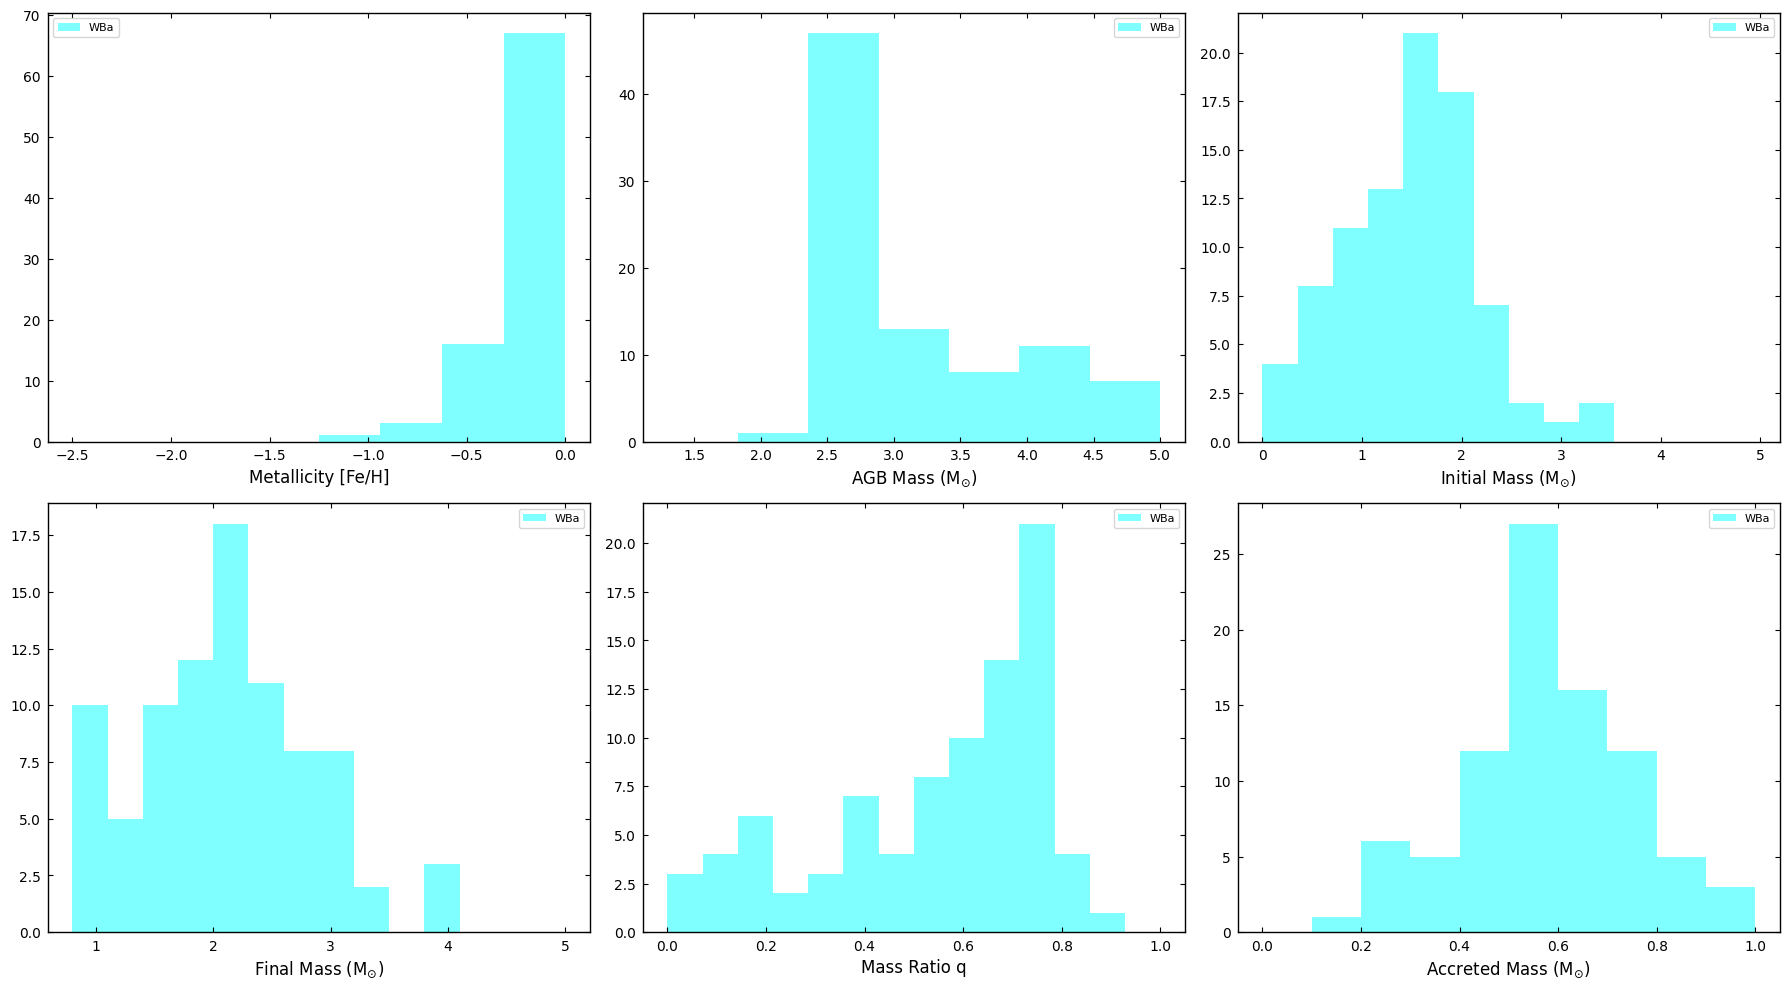

In [26]:
# make the same plot but with only the SBa stars
# plot histograms of all medians for each of the 4 parameters, split by the stellar type if available
def plot_all_median_histograms(all_stats):
    """Plot histograms of median values for all stars"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    all_types = all_stats['Star_Type'].unique()

    xlabels = ['Metallicity [Fe/H]', 'AGB Mass (M$_{\odot}$)', 'Initial Mass (M$_{\odot}$)', 'Final Mass (M$_{\odot}$)', 'Mass Ratio q', 'Accreted Mass (M$_{\odot}$)']
    for star_type in all_types:
        # combine CEMP-r/s with CEMP-s
        #if star_type == 'CEMP-r/s':
        #    star_type = 'CEMP-s'
        #    type_stats = all_stats[all_stats['Star_Type'] == star_type]
#
        #    for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
        #       ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='red')
        #       ax.legend(fontsize=8)
        #       ax.set_xlabel(xlabel)
#
        #elif star_type == 'CH':
        #    type_stats = all_stats[all_stats['Star_Type'] == star_type]
        #    for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
        #       ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='darkorange')
        #       ax.legend(fontsize=8)
        #       ax.set_xlabel(xlabel)
#
        if star_type == 'WBa':
            type_stats = all_stats[all_stats['Star_Type'] == star_type]
            for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
               ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='cyan')
               ax.legend(fontsize=8)
               ax.set_xlabel(xlabel)

        #if star_type == 'SBa':
        #    type_stats = all_stats[all_stats['Star_Type'] == star_type]
        #    for ax, mean_param, bins, xlabel in zip(axes.flatten(), ['Metallicity_Mean', 'AGB_Mass_Mean', 'Initial_Mass_Mean', 'Final_Mass_Mean', 'Mass_Ratio_q_Mean', 'Accreted_Mass_Mean'], [metal_bins, agb_bins, minit_bins, mfinal_bins, q_bins, macc_bins], xlabels):
        #       ax.hist(type_stats[mean_param].dropna(), bins=bins, alpha=0.5, histtype='stepfilled', label=star_type, color='royalblue')
        #       ax.legend(fontsize=8)
        #       ax.set_xlabel(xlabel)


    #for ax, mean_param, title in zip(axes.flatten(), mean_params, titles):
    #    ax.hist(all_stats[mean_param].dropna(), bins=20, alpha=0.5, color='orange', edgecolor='black')
    #    ax.set_title(f'Histogram of {title}')
    #    ax.set_xlabel(title)
    #    ax.set_ylabel('Number of Stars')
    
    plt.tight_layout()

plot_all_median_histograms(all_stats)

In [3]:
# use the data in the master_table and the stats histograms and make a plot of the final mass, but
# identify which stars are dwarfs / giants by their logg values
# logg < 3.5 are giants, logg >= 3.5 are dwarfs

# do this just for the strong Ba stars
strong_ba_stars = all_stats[all_stats['Star_Type'] == 'SBa']
weak_ba_stars = all_stats[all_stats['Star_Type'] == 'WBa']
CH_stars = all_stats[all_stats['Star_Type'] == 'CH']
CEMPs_stars = all_stats[all_stats['Star_Type'] == 'CEMP-s']

def split_plot_by_logg(all_stats, master_table):
    """Plot distributions split by dwarfs and giants based on logg"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Merge all_stats with master_table to get logg values
    merged_df = all_stats.merge(master_table[['stars', 'logg']], left_on='Star', right_on='stars', how='left')
    
    # Classify stars as dwarfs or giants based on logg
    # dwarfs > 3.5
    # 3.5 > subgiants > 3.0
    # 3.0 > giants
    merged_df['Type'] = np.where(merged_df['logg'] < 3.0, 'Giant', 'Dwarf')
    
    # Plot histograms split by evolutionary states
    for star_type, color in zip(['Giant', 'Subgiant', 'Dwarf'], ['crimson', 'darkorange', 'blue']):
        subset = merged_df[merged_df['Type'] == star_type]
        ax.hist(subset['Mass_Ratio_q_Mean'].dropna(), bins=20, alpha=0.5, label=star_type, color=color)
    
    ax.set_xlabel('Mass Ratio')
    ax.set_ylabel('Number of Stars')
    ax.set_title('Mass Ratio Distribution by Stellar Type')
    ax.legend()

NameError: name 'all_stats' is not defined

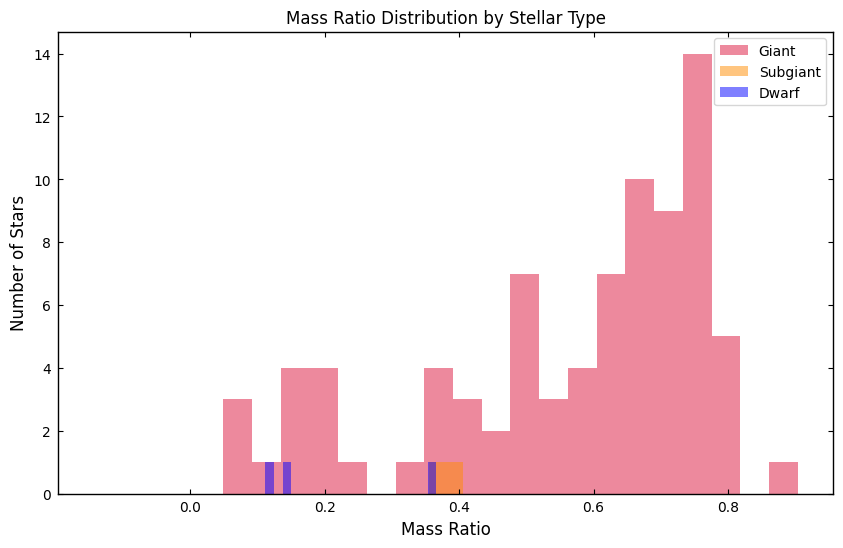

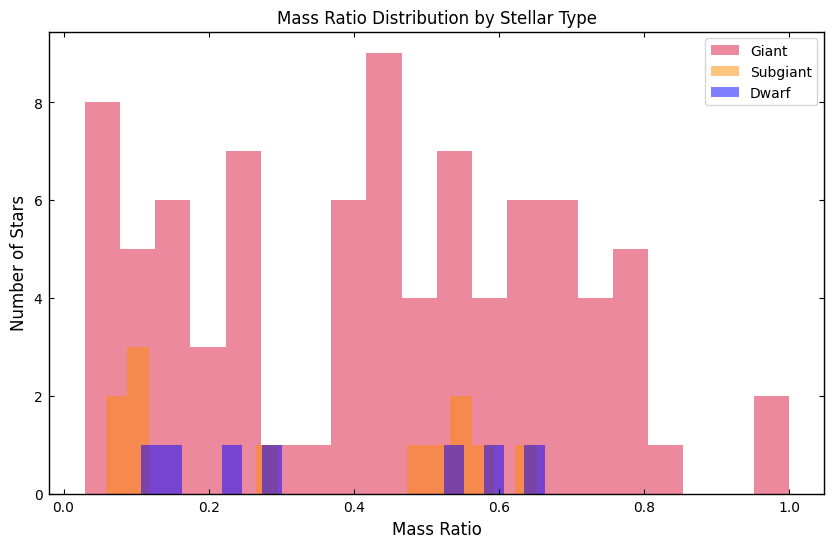

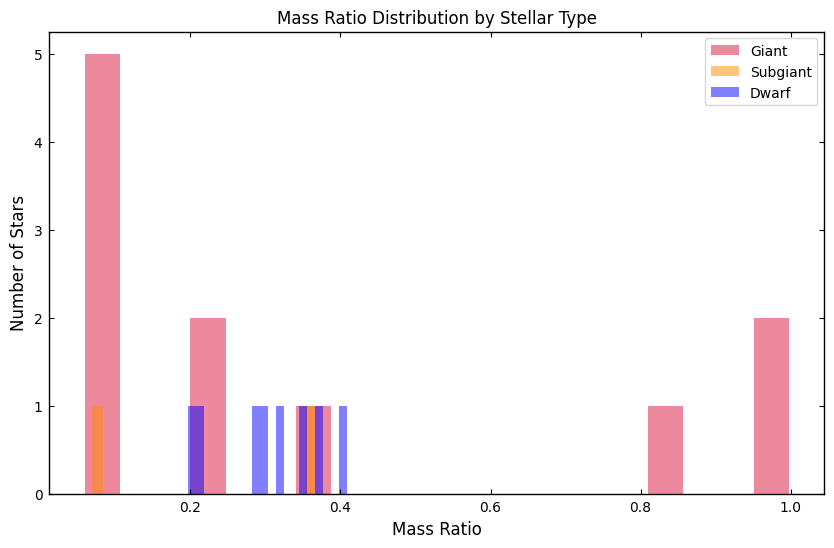

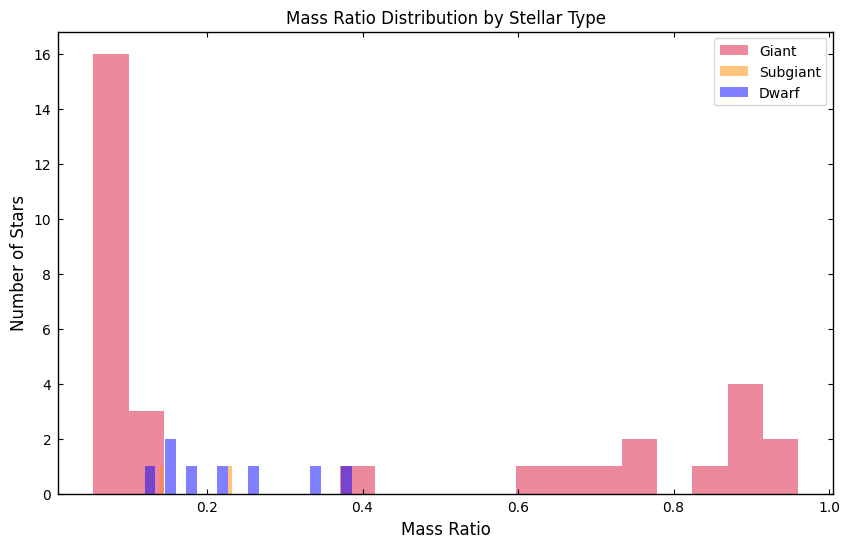

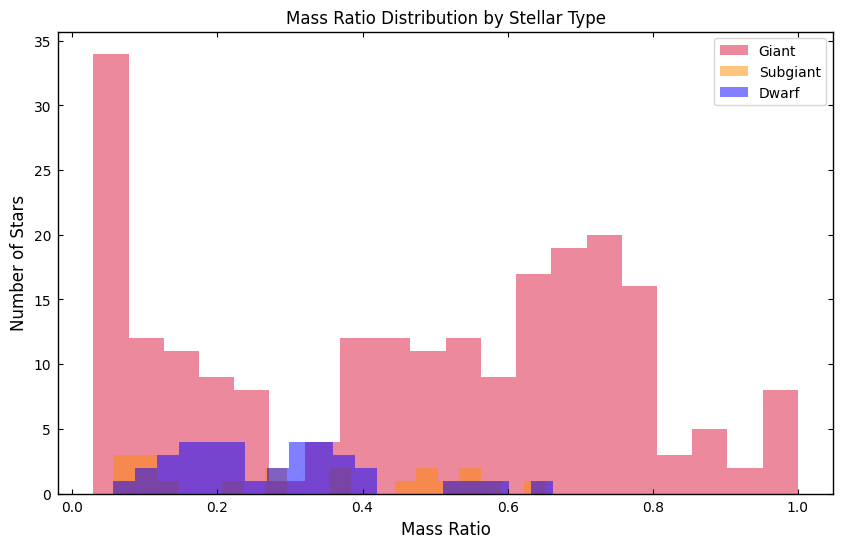

In [81]:
split_plot_by_logg(weak_ba_stars, master_table)
split_plot_by_logg(strong_ba_stars, master_table)
split_plot_by_logg(CH_stars, master_table)
split_plot_by_logg(CEMPs_stars, master_table)
split_plot_by_logg(all_stats, master_table)